# Install Libraries

In [8]:
!pip install -q transformers datasets torch matplotlib numpy tqdm

# Imports

In [9]:
import torch
import numpy as np
import base64
import random
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import DataLoader
from tqdm import tqdm

# Config

In [10]:
torch.manual_seed(42)
random.seed(42)

MODEL_ID = "gpt2"
MAX_SAMPLES = 500
SEQ_LEN = 128
BATCH_SIZE = 8
LEARNING_RATE = 5e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# This a python code dataset on huggingface
hf_dataset = load_dataset("flytech/python-codes-25k", split="train")

Using device: cuda


# Dataset Creation

In [11]:
def generate_benign_code(dataset, num_samples):
    # Pulling code part from the dataset
    snippets = []
    for i in range(num_samples):
        code = dataset[i]['output']
        snippets.append(code)
    return snippets

def obfuscate_code(code_str):
    # Creating Junk dataset
    b64_encoded = base64.b64encode(code_str.encode('utf-8')).decode('utf-8')
    junk_var_1 = f"_0x{random.randint(1000,9999):x}"
    junk_var_2 = f"_0x{random.randint(1000,9999):x}"
    
    obfuscated = (
        f"{junk_var_1} = {random.randint(1, 100)}\n"
        f"{junk_var_2} = lambda x: x * {junk_var_1}\n"
        f"import base64\n"
        f"exec(base64.b64decode(b'{b64_encoded}').decode('utf-8'))\n"
    )
    return obfuscated

benign_texts = generate_benign_code(hf_dataset, MAX_SAMPLES)
obfuscated_texts = [obfuscate_code(text) for text in benign_texts]

# Tokenization and DataLoader

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

def prepare_dataloader(texts):
    encodings = tokenizer(
        texts, 
        truncation=True, 
        padding="max_length", 
        max_length=SEQ_LEN, 
        return_tensors="pt"
    )
    dataset = torch.utils.data.TensorDataset(encodings.input_ids, encodings.attention_mask)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

loader_benign = prepare_dataloader(benign_texts)
loader_obfuscated = prepare_dataloader(obfuscated_texts)

# Training and Measuring Loss for a weak learner

In [13]:
# Traing and measuring loss for a weak learner
def train_and_measure(loader, desc):
    config = AutoModelForCausalLM.from_pretrained(MODEL_ID).config
    model = AutoModelForCausalLM.from_config(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    loss_history = []
    model.train()
    for batch in tqdm(loader, desc=f"Evaluating {desc}"):
        input_ids, attention_mask = [b.to(device) for b in batch]
        
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
        loss = outputs.loss
        
        loss_history.append(loss.item())
        loss.backward()
        optimizer.step()
        
    return np.array(loss_history)

losses_benign = train_and_measure(loader_benign, "Benign Code")
losses_obfuscated = train_and_measure(loader_obfuscated, "Obfuscated Code")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Evaluating Benign Code: 100%|██████████| 63/63 [00:17<00:00,  3.54it/s]


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Evaluating Obfuscated Code: 100%|██████████| 63/63 [00:18<00:00,  3.47it/s]


# Metric Calculation

In [14]:
# Calculating time bounded entropy baseline and epiplexity
def calculate_metrics(losses):
    baseline_steps = max(1, len(losses) // 10)
    entropy_ht = np.mean(losses[-baseline_steps:])
    epiplexity = np.sum(np.maximum(losses - entropy_ht, 0))
    return epiplexity, entropy_ht

epi_benign, ent_benign = calculate_metrics(losses_benign)
epi_obfuscated, ent_obfuscated = calculate_metrics(losses_obfuscated)

print("Final Epiplexity Measurement")
print(f"Benign Trace     -> Epiplexity (Structure): {epi_benign:.2f} | Entropy (Noise): {ent_benign:.2f}")
print(f"Obfuscated Trace -> Epiplexity (Structure): {epi_obfuscated:.2f} | Entropy (Noise): {ent_obfuscated:.2f}")

Final Epiplexity Measurement
Benign Trace     -> Epiplexity (Structure): 65.53 | Entropy (Noise): 3.32
Obfuscated Trace -> Epiplexity (Structure): 62.59 | Entropy (Noise): 3.91


# Vizualization

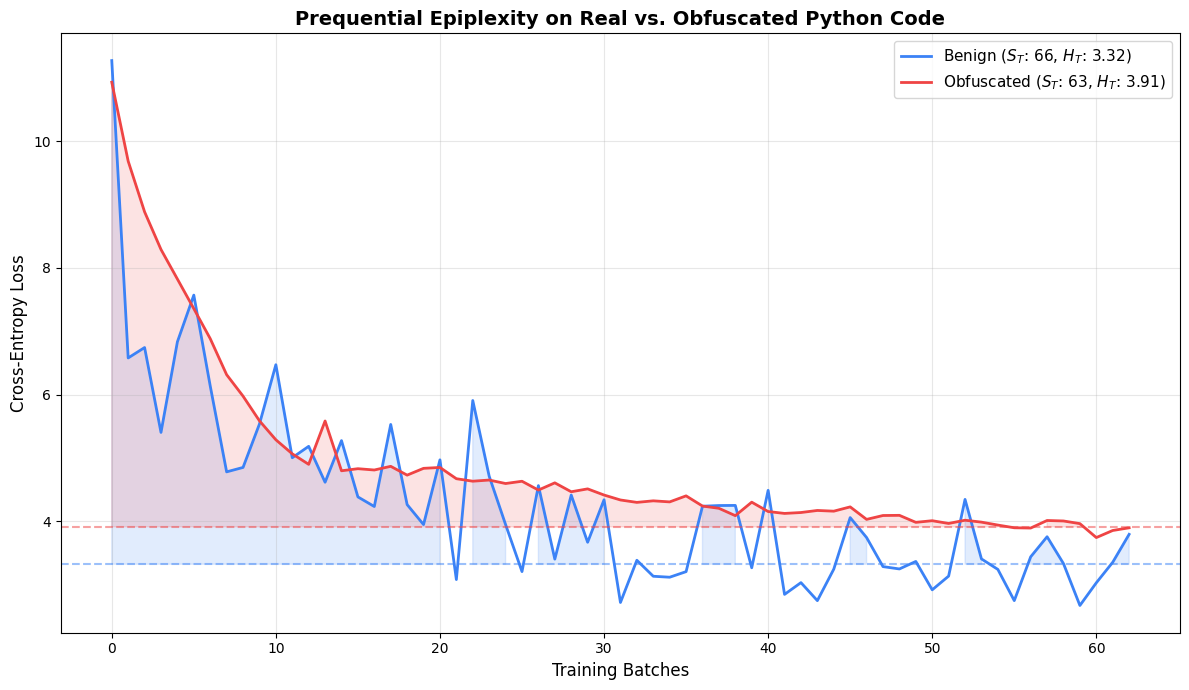

In [15]:
plt.figure(figsize=(12, 7))
plt.plot(losses_benign, label=f'Benign ($S_T$: {epi_benign:.0f}, $H_T$: {ent_benign:.2f})', color='#3b82f6', linewidth=2)
plt.plot(losses_obfuscated, label=f'Obfuscated ($S_T$: {epi_obfuscated:.0f}, $H_T$: {ent_obfuscated:.2f})', color='#ef4444', linewidth=2)

plt.axhline(y=ent_benign, color='#3b82f6', linestyle='--', alpha=0.5)
plt.axhline(y=ent_obfuscated, color='#ef4444', linestyle='--', alpha=0.5)

plt.fill_between(range(len(losses_benign)), ent_benign, losses_benign, where=(losses_benign > ent_benign), color='#3b82f6', alpha=0.15)
plt.fill_between(range(len(losses_obfuscated)), ent_obfuscated, losses_obfuscated, where=(losses_obfuscated > ent_obfuscated), color='#ef4444', alpha=0.15)

plt.title("Prequential Epiplexity on Real vs. Obfuscated Python Code", fontweight='bold', fontsize=14)
plt.xlabel("Training Batches", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()